In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
print('Missing values before imputation:')
print(df.isnull().sum())

# Impute categorical columns with mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

# Impute numerical column with median
median_value = df['Courier_Experience_yrs'].median()
df['Courier_Experience_yrs'].fillna(median_value, inplace=True)

print('\nMissing values after imputation:')
print(df.isnull().sum())

Missing values before imputation:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Missing values after imputation:
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   object 
 3   Traffic_Level           1000 non-null   object 
 4   Time_of_Day             1000 non-null   object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB

DataFrame Description (Numerical Columns):
          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000             1000.000000   
mean    500.500000    10.05

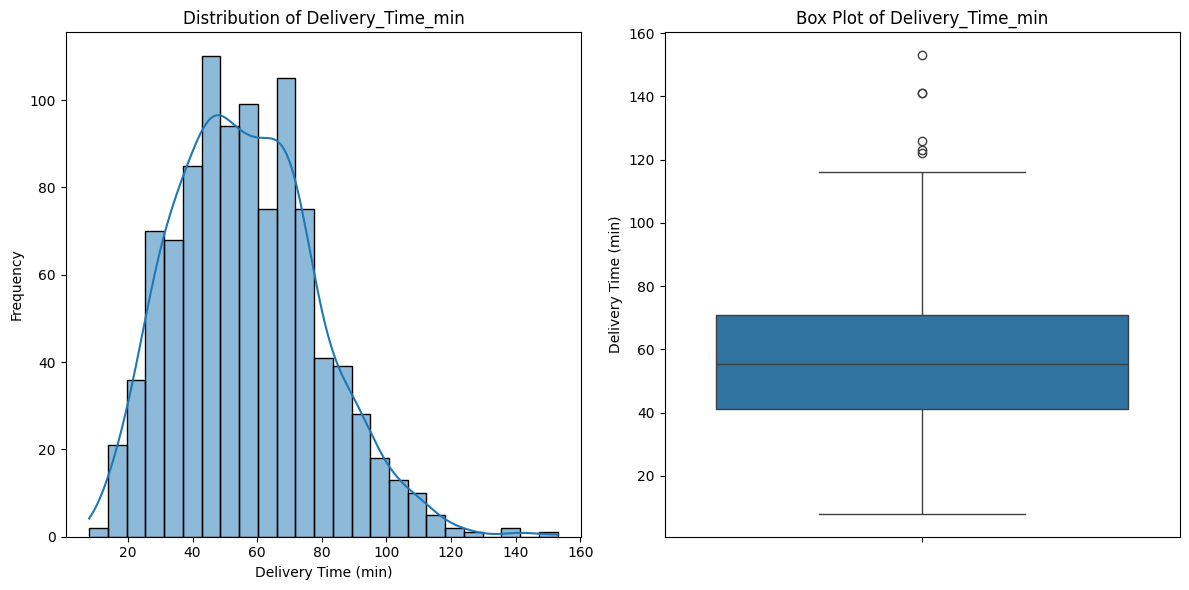

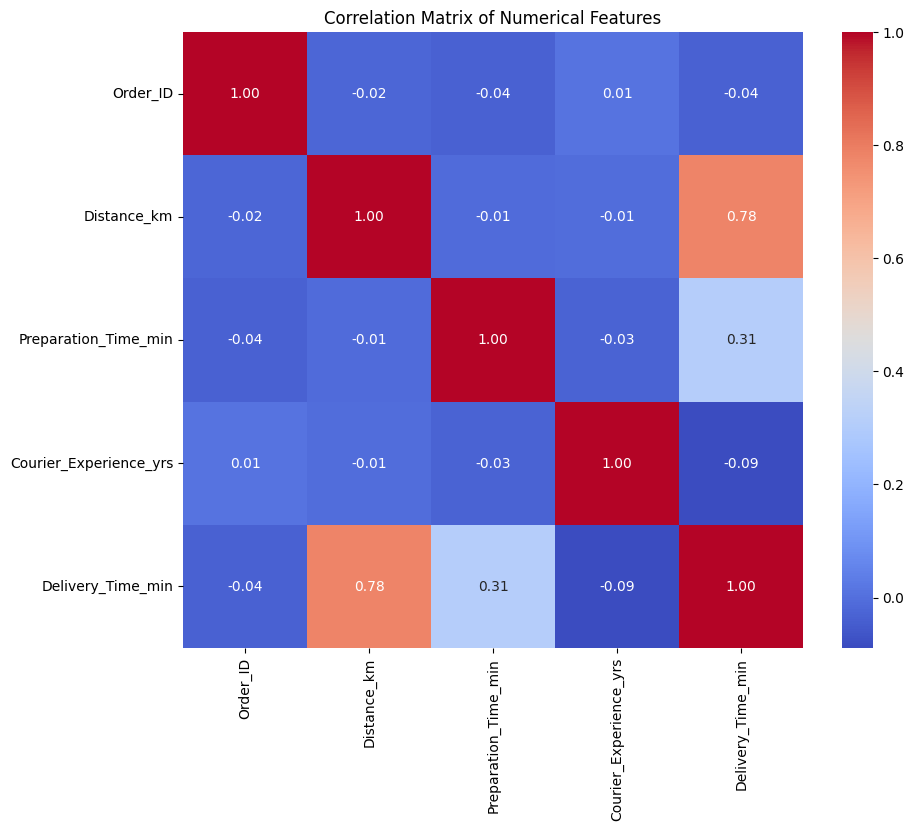

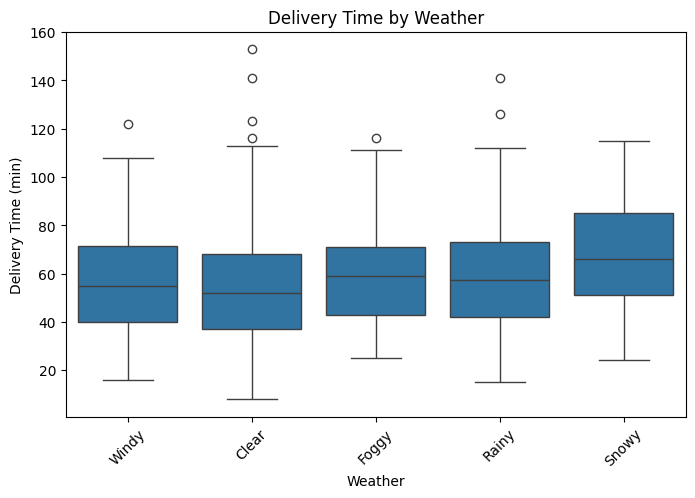

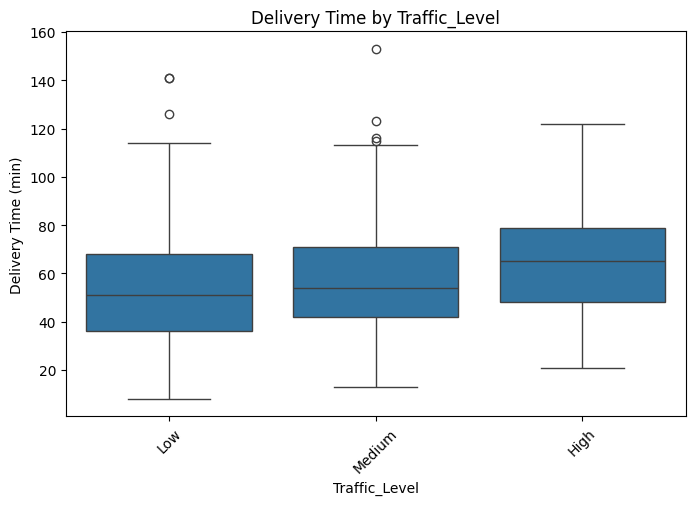

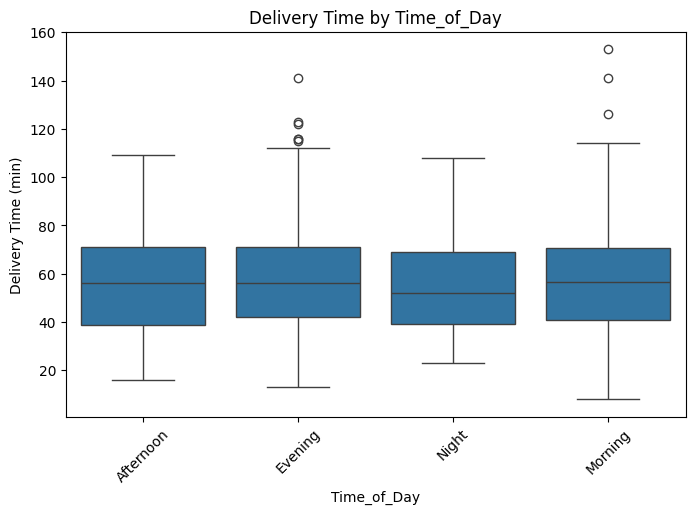

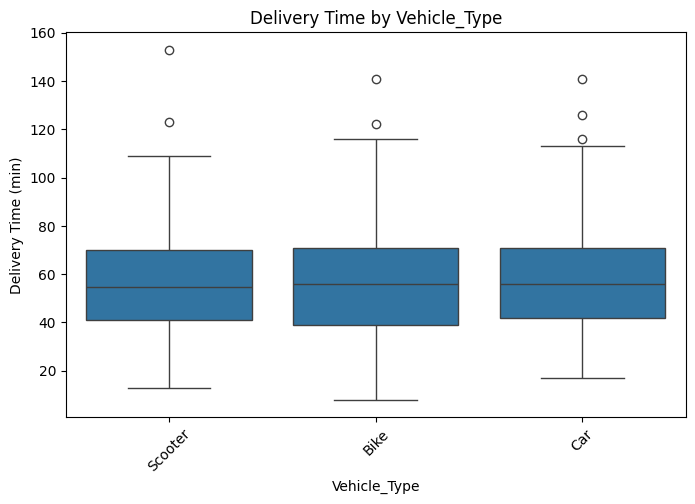

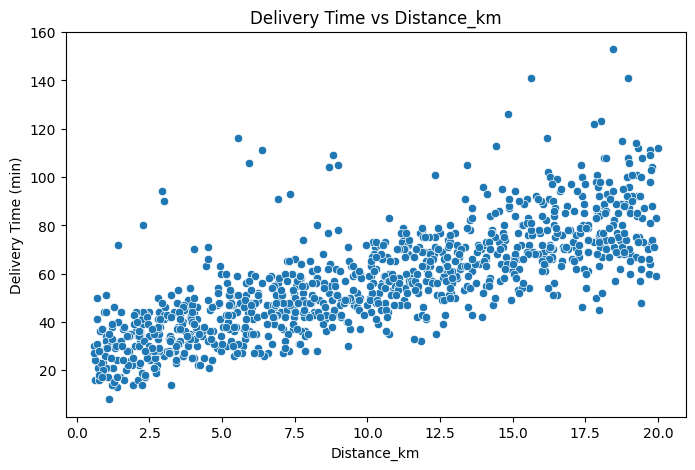

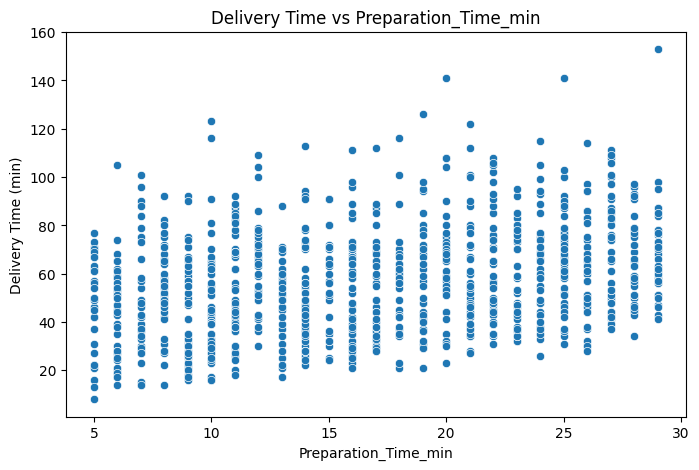

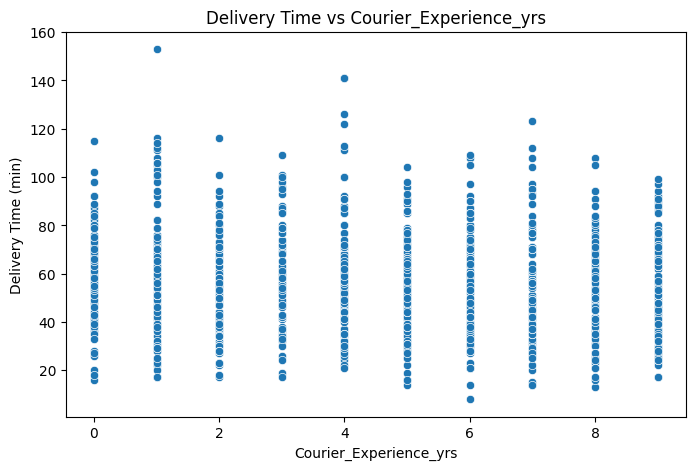

In [5]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Description (Numerical Columns):')
print(df.describe())

print('\nDataFrame Description (Categorical Columns):')
print(df.describe(include='object'))

# Distribution of the target variable: Delivery_Time_min
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title('Distribution of Delivery_Time_min')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery_Time_min')
plt.ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

# Analyze correlation for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Relationship between categorical features and Delivery_Time_min
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45)
    plt.show()

# Relationship between numerical features and Delivery_Time_min (excluding Order_ID and target itself)
numerical_cols = df.select_dtypes(include=np.number).columns.drop(['Order_ID', 'Delivery_Time_min'])

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time vs {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.show()

In [6]:
from scipy.stats import f_oneway

print('--- Statistical Testing for Feature Selection ---')

# 1. Numerical Features: Correlation with Delivery_Time_min
print('\nCorrelation of Numerical Features with Delivery_Time_min:')
numerical_cols_for_corr = df.select_dtypes(include=np.number).columns.drop(['Order_ID', 'Delivery_Time_min'])

correlation_with_target = df[numerical_cols_for_corr].corrwith(df['Delivery_Time_min']).sort_values(ascending=False)
print(correlation_with_target)

# 2. Categorical Features: ANOVA Test
print('\nANOVA Test for Categorical Features vs. Delivery_Time_min:')
categorical_cols = df.select_dtypes(include='object').columns

anova_results = {}
for col in categorical_cols:
    groups = [df['Delivery_Time_min'][df[col] == category] for category in df[col].unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results[col] = {'F-statistic': f_stat, 'P-value': p_val}

    print(f'\nFeature: {col}')
    print(f'  F-statistic: {f_stat:.3f}')
    print(f'  P-value: {p_val:.3f}')
    if p_val < 0.05:
        print(f'  Conclusion: {col} is statistically significant (p < 0.05).')
    else:
        print(f'  Conclusion: {col} is not statistically significant (p >= 0.05).')

print('\n--- Summary of Best Features ---')
print('Features with strong correlation (numerical) or significant p-value (categorical) are likely the ' \
      'best features for predicting Delivery_Time_min.')

--- Statistical Testing for Feature Selection ---

Correlation of Numerical Features with Delivery_Time_min:
Distance_km               0.780998
Preparation_Time_min      0.307350
Courier_Experience_yrs   -0.089111
dtype: float64

ANOVA Test for Categorical Features vs. Delivery_Time_min:

Feature: Weather
  F-statistic: 10.499
  P-value: 0.000
  Conclusion: Weather is statistically significant (p < 0.05).

Feature: Traffic_Level
  F-statistic: 19.751
  P-value: 0.000
  Conclusion: Traffic_Level is statistically significant (p < 0.05).

Feature: Time_of_Day
  F-statistic: 0.347
  P-value: 0.792
  Conclusion: Time_of_Day is not statistically significant (p >= 0.05).

Feature: Vehicle_Type
  F-statistic: 0.589
  P-value: 0.555
  Conclusion: Vehicle_Type is not statistically significant (p >= 0.05).

--- Summary of Best Features ---
Features with strong correlation (numerical) or significant p-value (categorical) are likely the best features for predicting Delivery_Time_min.


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Create a copy of the dataframe to avoid modifying the original 'df' in place
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to all categorical columns (excluding 'Order_ID' and 'Delivery_Time_min')
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Define target variable (y) and features (X)
y = df_encoded['Delivery_Time_min']
X = df_encoded.drop(columns=['Order_ID', 'Delivery_Time_min'])

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

print('\nFirst 5 rows of X_train (after label encoding):')
print(X_train.head())

Shape of X_train: (800, 7)
Shape of X_test: (200, 7)
Shape of y_train: (800,)
Shape of y_test: (200,)

First 5 rows of X_train (after label encoding):
     Distance_km  Weather  Traffic_Level  Time_of_Day  Vehicle_Type  \
29         18.05        0              2            1             2   
535         2.14        0              0            1             0   
695         3.23        0              0            0             0   
557         7.51        2              1            1             1   
836         4.62        2              2            0             1   

     Preparation_Time_min  Courier_Experience_yrs  
29                     10                     7.0  
535                    18                     3.0  
695                    17                     9.0  
557                    27                     6.0  
836                     8                     3.0  


In [10]:
df_encoded.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68


In [11]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor with default parameters
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Default Decision Tree Regressor model created and trained successfully.")

Default Decision Tree Regressor model created and trained successfully.


In [12]:
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score on the test set: {r2:.2f}")

# Calculate Mean Squared Error (MSE) - another common regression metric
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on the test set: {mse:.2f}")

R-squared score on the test set: 0.49
Mean Squared Error on the test set: 226.82


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Default Random Forest Regressor model created and trained successfully.")

Default Random Forest Regressor model created and trained successfully.


In [15]:
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate R-squared score for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest R-squared score on the test set: {r2_rf:.2f}")

# Calculate Mean Squared Error (MSE) for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error on the test set: {mse_rf:.2f}")

Random Forest R-squared score on the test set: 0.78
Random Forest Mean Squared Error on the test set: 100.12


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distributions for Random Forest
param_distributions = {
    'n_estimators': randint(50, 200),  # Number of trees in the forest (random integer between 50 and 200)
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum depth of the tree
    'min_samples_split': randint(2, 11), # Minimum number of samples required to split an internal node (random integer between 2 and 10)
    'min_samples_leaf': randint(1, 5)    # Minimum number of samples required to be at a leaf node (random integer between 1 and 4)
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of the solution.
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_distributions,
                                   n_iter=50, cv=5, n_jobs=-1, verbose=2, scoring='r2', random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best hyperparameters found: {random_search.best_params_}")
print(f"Best R-squared score from random search: {random_search.best_score_:.2f}")

# Get the best model
best_rf_model_rs = random_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_rf_rs = best_rf_model_rs.predict(X_test)
r2_best_rf_rs = r2_score(y_test, y_pred_best_rf_rs)
mse_best_rf_rs = mean_squared_error(y_test, y_pred_best_rf_rs)

print(f"R-squared score on test set with best Random Forest model (Randomized Search): {r2_best_rf_rs:.2f}")
print(f"Mean Squared Error on test set with best Random Forest model (Randomized Search): {mse_best_rf_rs:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters found: {'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 180}
Best R-squared score from random search: 0.71
R-squared score on test set with best Random Forest model (Randomized Search): 0.78
Mean Squared Error on test set with best Random Forest model (Randomized Search): 96.78


In [19]:
import pickle

# Save the best Random Forest model
model_filename = 'best_random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model_rs, file)
print(f"Best Random Forest model saved to {model_filename}")

# Save the LabelEncoder object
# Assuming 'le' is the LabelEncoder instance used for encoding categorical features
label_encoder_filename = 'label_encoder.pkl'
with open(label_encoder_filename, 'wb') as file:
    pickle.dump(le, file)
print(f"LabelEncoder saved to {label_encoder_filename}")

Best Random Forest model saved to best_random_forest_model.pkl
LabelEncoder saved to label_encoder.pkl


In [21]:
X.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs'],
      dtype='object')